# Streaming and exporting to numpy

Companion notebook for the [Streaming](https://ddacs.readthedocs.io/en/latest/tutorials/streaming/) tutorial. It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

## Walkthrough

1. build a custom view with `ddacs.add_view`,
2. iterate the view offline with `ddacs.streaming.iter_view` (no PyTorch, no `mlcroissant.Dataset.records()` FileSet walk),
3. export the view as flat `.npy` files with `ddacs.streaming.export_to_numpy`, using a `record_transform` that geometrically normalises the formed-blank point cloud to `[-1, 1]` and stores the per-record `center_mm` / `scale_mm` so de-normalisation is reversible,
4. read the exported tensors back via `np.load(..., mmap_mode='r')`,
5. time both paths back to back so the speedup is concrete,
6. visualise the normalised sample directly from the numpy shards.

## Assumptions

- This notebook lives in `notebooks/` of the repository. The data directory `./data` therefore resolves to `../data` from here.
- `ddacs download --small` (or larger) has been run, so the bundled sample simulation `258864.zip` is present. Everything below scopes to that one simulation via `sim_ids=[SAMPLE_SIM_ID]`, so a one-zip layout is enough to run the entire notebook.
- The exported `.npy` files are written into `../data/tutorial_export/`. Safe to delete after the notebook runs.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import ddacs

DATA_DIR       = Path('../data')
EXPORT_DIR     = DATA_DIR / 'tutorial_export'
SAMPLE_SIM_ID  = 258864    # bundled with `ddacs download --small`
ROCKET         = sns.color_palette('rocket', as_cmap=True)

print('ddacs', ddacs.__version__)

ddacs 3.0.0


## 1. Build a custom view

We reuse the `add_view` pattern from the [Build your own view](https://ddacs.readthedocs.io/en/latest/tutorials/views/) tutorial: pull two timesteps of the blank's node displacement so the per-record output is just `(n_nodes, 3)` forming and springback states. The published manifest stays unchanged; only the in-memory `ds` grows.

In [2]:
ds = ddacs.load(data_dir=DATA_DIR)
ddacs.add_view(
    ds,
    'my-view',
    fields={
        'trajectory': ('op10_blank_node_displacement', None),       # all 4 timesteps
        'forming':    ('op10_blank_node_displacement', 2),          # one timestep
        'springback': ('op10_blank_node_displacement', [2, 3]),     # subset of timesteps
        'thickness':  'op10_blank_element_shell_thickness',         # whole field, shortcut form
    },
)
print('record_sets after add_view:')
for rs in ds.metadata.record_sets:
    print(f'  {rs.id}')

record_sets after add_view:
  process-parameters
  field-map
  simulation-provenance
  springback-minimal
  springback-prediction
  forming-snapshot
  cutting-view
  my-view


## 2. Preview one record with `streaming.iter_view`

`ddacs.streaming.iter_view(view='my-view', dataset=ds)` is the plain-Python counterpart to `DDACSDataset.__iter__`. No PyTorch dependency, no `mlcroissant.Dataset.records()` FileSet walk (the one that takes minutes on the full release). It opens each zip on demand and yields one `dict[str, np.ndarray]` per simulation, with every alias from `my-view` already sliced according to its JSONPath transform.

The cell below pulls the single bundled simulation (`sim_ids=[SAMPLE_SIM_ID]`) and prints the shapes of the record so the data layout is concrete before we touch the export. The same `sim_ids=` / `where=` arguments work for any subset; replace with `sim_ids=None` to walk every simulation in `process_parameters.csv`.

In [3]:
for rec in ddacs.streaming.iter_view('my-view', data_dir=DATA_DIR, dataset=ds, sim_ids=[SAMPLE_SIM_ID]):
    for alias, value in rec.items():
        print(f'  {alias:12s} shape={value.shape}  dtype={value.dtype}')
    break

  trajectory   shape=(4, 11236, 3)  dtype=float64
  forming      shape=(11236, 3)  dtype=float64
  springback   shape=(2, 11236, 3)  dtype=float64
  thickness    shape=(4, 11025)  dtype=float64


## 3. Export to numpy with geometric normalisation

`export_to_numpy` walks the view once, applies any per-field or whole-record transforms, and writes each output alias into its own pre-allocated `.npy` memmap of shape `(n_sims, *field_shape)`. It also writes `sim_ids.npy` so the row order is recoverable.

The `record_transform` here does three useful things at once and is a good template for the way training pipelines actually consume the dataset:

1. **Normalise the point cloud geometry.** ML point-cloud architectures (PointNet++, DGCNN, ...) almost always expect inputs in a unit cube. We centre `forming` on its centroid and scale by the largest absolute coordinate so the cloud lives in `[-1, 1]`.
2. **Derive the training target.** The springback `delta = springback[1] - forming` is what a model would predict; we precompute it once at export time instead of every epoch. It is kept in physical mm so loss values stay interpretable.
3. **Preserve the de-normalisation constants.** The per-record `center_mm` and `scale_mm` are scalar (3-vector and float respectively) and ride alongside the tensors so any downstream code can map a prediction back to physical mm without re-opening the HDF5 file.

`transforms={alias: fn}` would do the same on a single field; `record_transform` is the right tool when the output keys do not match the input keys, as here.

In [4]:
def normalize_and_emit(rec):
    """Centre+scale `forming` to [-1, 1] and derive the springback delta."""
    nodes  = rec['forming']                       # (n_nodes, 3) in mm
    center = nodes.mean(axis=0)                   # (3,) part centroid
    scale  = float(np.abs(nodes - center).max())  # half-extent along the dominant axis
    return {
        'forming':   ((nodes - center) / scale).astype(np.float32),  # in [-1, 1]
        'delta':     (rec['springback'][1] - nodes).astype(np.float32),  # mm, absolute
        'center_mm': center.astype(np.float32),
        'scale_mm':  np.float32(scale),
    }


t0 = time.perf_counter()
paths = ddacs.streaming.export_to_numpy(
    'my-view',
    EXPORT_DIR,
    data_dir=DATA_DIR,
    dataset=ds,
    sim_ids=[SAMPLE_SIM_ID],
    record_transform=normalize_and_emit,
)
t_export = time.perf_counter() - t0

print(f'export_to_numpy: {t_export:6.2f} s')
for alias, path in paths.items():
    size_kb = path.stat().st_size / 1024
    print(f'  {alias:10s} -> {path}   ({size_kb:7.1f} KB)')

export_to_numpy:   0.46 s
  forming    -> ../data/tutorial_export/forming.npy   (  131.8 KB)
  delta      -> ../data/tutorial_export/delta.npy   (  131.8 KB)
  center_mm  -> ../data/tutorial_export/center_mm.npy   (    0.1 KB)
  scale_mm   -> ../data/tutorial_export/scale_mm.npy   (    0.1 KB)
  sim_ids    -> ../data/tutorial_export/sim_ids.npy   (    0.1 KB)


## 4. Read the shards back

Now training-side code never touches HDF5 or zip again. `np.load(..., mmap_mode='r')` returns a memory-mapped array; indexing by row is a single mmap slice, no decompression. The same field aliases used in the view are the file names.

The scalar metadata (`center_mm`, `scale_mm`) sits alongside the tensors at the same row index, which is exactly the demonstration of "non-spatial values" the tutorial promised: print them as numbers.

In [5]:
sim_ids   = np.load(paths['sim_ids'])
forming   = np.load(paths['forming'],   mmap_mode='r')
delta     = np.load(paths['delta'],     mmap_mode='r')
center_mm = np.load(paths['center_mm'], mmap_mode='r')
scale_mm  = np.load(paths['scale_mm'],  mmap_mode='r')

print(f'sim_ids:   shape={sim_ids.shape}   dtype={sim_ids.dtype}')
print(f'forming:   shape={forming.shape}   dtype={forming.dtype}   range=[{forming.min():+.3f}, {forming.max():+.3f}]')
print(f'delta:     shape={delta.shape}     dtype={delta.dtype}')
print(f'center_mm: shape={center_mm.shape}     dtype={center_mm.dtype}   values={center_mm[0]}')
print(f'scale_mm:  shape={scale_mm.shape}        dtype={scale_mm.dtype}   value={float(scale_mm[0]):.3f}')

sim_ids:   shape=(1,)   dtype=int64
forming:   shape=(1, 11236, 3)   dtype=float32   range=[-0.954, +1.000]
delta:     shape=(1, 11236, 3)     dtype=float32
center_mm: shape=(1, 3)     dtype=float32   values=[47.913727 47.896564 13.933755]
scale_mm:  shape=(1,)        dtype=float32   value=50.223


The `center_mm` and `scale_mm` shards are the general pattern for **storing custom per-record data alongside the tensors**. Anything that fits in a numpy array (scalar, vector, tensor, integer label, downsampled image, ...) can ride next to the main fields with the same row index, declared by the `record_transform`. No need for a separate metadata file.

A typical use: convert a prediction made in the normalised cube back to physical mm by inverting the transform you applied at export. The cell below does the round trip for record `0` and prints both ranges so the inversion is visible.

In [6]:
forming_mm = forming[0] * scale_mm[0] + center_mm[0]

print(f'normalised forming[0] range: [{forming[0].min():+.3f}, {forming[0].max():+.3f}]   (in [-1, 1])')
print(f'de-norm forming_mm    range: [{forming_mm.min():+.3f}, {forming_mm.max():+.3f}] mm')

normalised forming[0] range: [-0.954, +1.000]   (in [-1, 1])
de-norm forming_mm    range: [+0.000, +98.136] mm


## 5. Time the two paths back to back

We iterate the same sample sim two ways and time both. Path A is `streaming.iter_view`, the same call we used in step 2. Path B walks the `delta` mmap directly. Both compute `sum |delta|` so we can verify numerical equality at the end. With a single sim the absolute numbers are tiny, but the **per-record ratio** is what carries over to a full training loop: multiply by your epoch's `n_sims` to see the real win.

In [7]:
# Path A: streaming.iter_view (re-decompresses each h5 chunk).
t0 = time.perf_counter()
stream_sum = 0.0
n = 0
for rec in ddacs.streaming.iter_view('my-view', data_dir=DATA_DIR, dataset=ds, sim_ids=[SAMPLE_SIM_ID]):
    stream_sum += float(np.abs(rec['springback'][1] - rec['forming']).sum())
    n += 1
t_stream = time.perf_counter() - t0

# Path B: numpy mmap (slice from pre-extracted shards).
t0 = time.perf_counter()
mmap_sum = float(sum(np.abs(delta[i]).sum() for i in range(len(delta))))
t_mmap = time.perf_counter() - t0

print(f'iter_view  : {n:4d} sim in {1000 * t_stream:7.2f} ms  ({1000 * t_stream / n:6.2f} ms/sim)  sum|delta|={stream_sum:.3f}')
print(f'numpy mmap : {len(delta):4d} sim in {1000 * t_mmap:7.2f} ms  ({1000 * t_mmap / len(delta):6.2f} ms/sim)  sum|delta|={mmap_sum:.3f}')
print()
print(f'per-record speedup: {t_stream / max(t_mmap, 1e-9):.1f}x faster after a one-time {1000 * t_export:.1f} ms export')

iter_view  :    1 sim in  185.47 ms  (185.47 ms/sim)  sum|delta|=7592.394
numpy mmap :    1 sim in    0.14 ms  (  0.14 ms/sim)  sum|delta|=7592.394

per-record speedup: 1373.4x faster after a one-time 455.1 ms export


## 6. Visualise a sample

The shards on disk are just numpy memmaps now, so we no longer need `open_h5` or any view machinery to look at one record. Pick row `0` and render its `forming` point cloud (already in `[-1, 1]` after the `record_transform`), coloured by the per-node springback magnitude `|delta|` in physical mm. This is exactly the data a training loop reads at iteration 0 — no rescaling, no mirroring.

`mirror=False` here because the normalisation centred the part on the origin and the quarter-symmetric mirror would overlay four copies on top of each other. To recover the full part in mm, multiply by `scale_mm[i]` and add `center_mm[i]` first (the `forming_mm` round trip we did in step 4).

sim_id    = 258864
forming   : shape=(11236, 3)  dtype=float32
  x range = [-0.954, +1.000]
  y range = [-0.954, +0.999]
  z range = [-0.269, +0.330]
|delta|   = [0.0000, 1.5357] mm


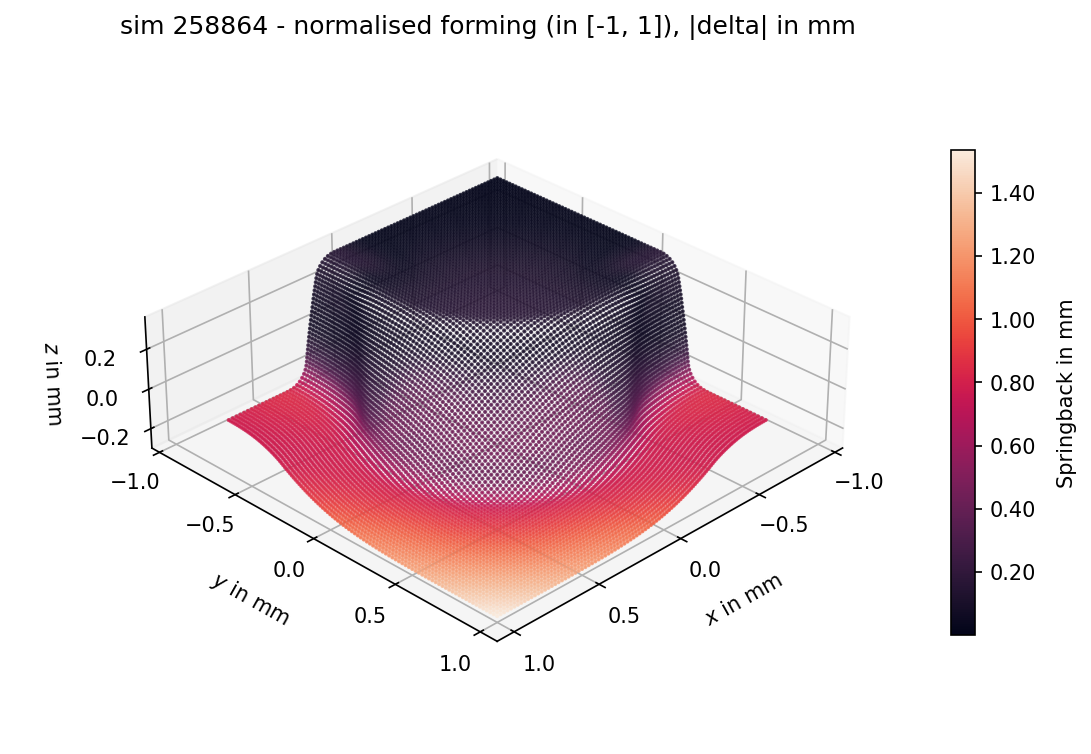

In [8]:
sample_idx       = 0
sample_sim_id    = int(sim_ids[sample_idx])
sample_forming   = forming[sample_idx]
sample_magnitude = np.linalg.norm(delta[sample_idx], axis=1)

print(f'sim_id    = {sample_sim_id}')
print(f'forming   : shape={sample_forming.shape}  dtype={sample_forming.dtype}')
print(f'  x range = [{sample_forming[:, 0].min():+.3f}, {sample_forming[:, 0].max():+.3f}]')
print(f'  y range = [{sample_forming[:, 1].min():+.3f}, {sample_forming[:, 1].max():+.3f}]')
print(f'  z range = [{sample_forming[:, 2].min():+.3f}, {sample_forming[:, 2].max():+.3f}]')
print(f'|delta|   = [{sample_magnitude.min():.4f}, {sample_magnitude.max():.4f}] mm')

ax, cbar = ddacs.plot_point_cloud(
    sample_forming,
    values=sample_magnitude,
    cmap=ROCKET,
    colorbar_label='Springback in mm',
    mirror=False,
)
ax.set_title(f'sim {sample_sim_id} - normalised forming (in [-1, 1]), |delta| in mm')
plt.show()

## Where to go next

- The same `transforms` / `record_transform` pattern is exactly how you turn a categorical column (e.g. `geometry='rectangular'`) into a small-int label: `transforms={'geometry': lambda v: {'rectangular': 0, 'concave': 1, 'convex': 2}[v.decode()]}`.
- `streaming.iter_view` is independent of the format: it transparently reads loose `h5/<sim_id>.h5` files (after `ddacs download --extract --remove-zip`) and zipped `h5/*.zip` archives. Loose files are picked when both exist because the BytesIO round trip is skipped.
- For batched, sharded training there is [`DDACSDataset`](https://ddacs.readthedocs.io/en/latest/tutorials/pytorch/) (PyTorch), which uses the same view-driven mechanics and benefits from the same `add_view` mutations via its `dataset=` kwarg.